# Issue 3 — Dataset Exploration

## Objective

Perform exploratory data analysis (EDA) on the network traffic dataset before beginning data preprocessing.

This notebook is **exploration and analysis only**. The raw dataset in `data/raw/` is loaded for inspection and analysis, but it is **not modified**.

### Scope of this issue

- Load the dataset
- Inspect dataset shape
- Inspect columns and data types
- Analyze missing values
- Analyze duplicate records
- Analyze class distribution
- Identify categorical and numerical features
- Visualize important feature distributions
- Analyze target/threat label distribution
- Identify potential data quality problems
- Record important observations

### Out of scope

The following steps are intentionally **not performed** in this issue:

- Final data cleaning
- Encoding categorical features
- Feature scaling/normalization
- Final feature selection
- Model training

## 1. Import Libraries

The notebook uses commonly available Python data-analysis and visualization libraries.

The code is written to work with datasets placed under `data/raw/`. It attempts to locate common CSV and text-based dataset files without modifying them.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Locate the Raw Dataset

The dataset for this issue must be stored in:

```text
data/raw/
```

The raw files are only read for exploration. No changes are written back to this directory.

In [ ]:
# Locate the project root from the notebook location.
# The notebook is expected to be located at:
# notebooks/01_dataset_exploration.ipynb

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = Path(r"C:\Users\dell\OneDrive\Desktop\Dataset for minor")

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Raw data directory: {RAW_DATA_DIR.resolve()}")

if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Raw data directory was not found: {RAW_DATA_DIR.resolve()}\n"
        "Please place the dataset inside data/raw/ before running the notebook."
    )

raw_files = sorted(
    [
        path for path in RAW_DATA_DIR.iterdir()
        if path.is_file() and path.suffix.lower() in {".csv", ".txt", ".data", ".dat"}
    ]
)

if not raw_files:
    raise FileNotFoundError(
        f"No CSV or text-based dataset files were found in {RAW_DATA_DIR.resolve()}."
    )

print("Available raw dataset files:")
for file in raw_files:
    print(f" - {file.name}")

Project root: C:\Users\dell\Documents\NTCF-minor-project-
Raw data directory: C:\Users\dell\OneDrive\Desktop\Dataset for minor
Available raw dataset files:
 - KDDTest+.txt
 - KDDTrain+.txt


## 3. Load the Dataset

The loader supports:

- `.csv` files
- `.txt`, `.data`, and `.dat` files

For comma-separated network intrusion datasets such as NSL-KDD, the notebook attempts to detect whether a header is present. If the file does not contain a header, generic column names are assigned.

The dataset is loaded into memory only. The original raw file is not changed.

In [ ]:
# Select the main dataset file.
# If multiple files are present, prefer a training file when available.
preferred_files = [
    file for file in raw_files
    if any(keyword in file.name.lower() for keyword in ["train", "combined", "dataset"])
]

DATA_PATH = preferred_files[0] if preferred_files else raw_files[0]

print(f"Selected dataset: {DATA_PATH.name}")

# Common NSL-KDD feature names.
NSL_KDD_COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

def load_raw_dataset(path):
    suffix = path.suffix.lower()

    # First attempt: standard comma-separated loading with header detection.
    if suffix == ".csv":
        df = pd.read_csv(path)
    else:
        # NSL-KDD-style files are comma-separated and commonly have no header.
        df = pd.read_csv(path, header=None)

        # If the number of columns matches NSL-KDD, assign known names.
        if df.shape[1] == len(NSL_KDD_COLUMNS):
            df.columns = NSL_KDD_COLUMNS
        else:
            # If the first row appears to be a header, use it as the header.
            first_row = df.iloc[0].astype(str).str.lower().tolist()
            known_terms = {"duration", "protocol_type", "service", "flag", "label"}
            if len(known_terms.intersection(set(first_row))) >= 2:
                df = pd.read_csv(path)

    return df

df = load_raw_dataset(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Selected dataset: KDDTrain+.txt
Dataset loaded successfully.
Rows: 125,973
Columns: 43


## 4. Initial Dataset Preview

The first and last records are inspected to understand the structure and values of the dataset.

In [ ]:
display(df.head())
display(df.tail())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
125968,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184,25,1.0,1.0,0.0,0.0,0.14,0.06,0.0,255,25,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,244,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,30,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,144,8,1.0,1.0,0.0,0.0,0.06,0.05,0.0,255,8,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,77,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


## 5. Dataset Shape

The dataset shape provides the number of observations and attributes available for analysis.

- **Rows** represent network traffic records.
- **Columns** represent traffic features and, usually, the target/threat label.

In [ ]:
n_rows, n_columns = df.shape

shape_summary = pd.DataFrame({
    "Measurement": ["Number of records", "Number of columns"],
    "Value": [n_rows, n_columns]
})

display(shape_summary)

,Measurement,Value
0,Number of records,125973
1,Number of columns,43


## 6. Columns and Data Types

This section documents every column and its detected data type.

The data types are important because they help identify:

- Categorical features
- Numerical features
- Possible type inconsistencies
- Columns that may require conversion in later preprocessing issues

No conversion is performed here.

In [ ]:
column_info = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean() * 100).values,
    "unique_values": df.nunique(dropna=True).values
})

display(column_info)

,column,dtype,non_null_count,missing_count,missing_percentage,unique_values
0,duration,int64,125973,0,0.0,2981
1,protocol_type,str,125973,0,0.0,3
2,service,str,125973,0,0.0,70
3,flag,str,125973,0,0.0,11
4,src_bytes,int64,125973,0,0.0,3341
5,dst_bytes,int64,125973,0,0.0,9326
6,land,int64,125973,0,0.0,2
7,wrong_fragment,int64,125973,0,0.0,3
8,urgent,int64,125973,0,0.0,4
9,hot,int64,125973,0,0.0,28


## 7. Missing Value Analysis

Missing values are counted and reported.

A missing value does not automatically mean that cleaning should be performed in this issue. The purpose here is to identify the problem so that the appropriate handling strategy can be decided during the preprocessing issues.

In [ ]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(
          missing_percentage=lambda x: (x["missing_count"] / len(df) * 100).round(2)
      )
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)

if missing_summary.empty:
    print("No missing values were detected.")
else:
    display(missing_summary)

No missing values were detected.


## 8. Duplicate Record Analysis

Duplicate records are counted to determine whether identical network traffic records exist.

Duplicates are **not removed** in this notebook because the issue is limited to exploration.

In [ ]:
duplicate_count = int(df.duplicated().sum())
duplicate_percentage = (duplicate_count / len(df) * 100) if len(df) else 0

duplicate_summary = pd.DataFrame({
    "Measurement": [
        "Duplicate records",
        "Duplicate percentage"
    ],
    "Value": [
        duplicate_count,
        f"{duplicate_percentage:.2f}%"
    ]
})

display(duplicate_summary)

if duplicate_count > 0:
    print("Example duplicate records:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No exact duplicate records were detected.")

,Measurement,Value
0,Duplicate records,0
1,Duplicate percentage,0.00%


No exact duplicate records were detected.


## 9. Identify the Target / Threat Label

Network intrusion datasets may use different names for the target column, such as:

- `label`
- `target`
- `class`
- `attack`
- `threat`

The notebook searches for common target column names. If no standard name is found, the final column is displayed as a possible candidate for manual confirmation.

The target column is not transformed in this issue.

In [ ]:
TARGET_CANDIDATES = [
    "label", "target", "class", "attack", "threat",
    "attack_type", "is_attack", "y"
]

normalized_columns = {
    str(column).strip().lower(): column
    for column in df.columns
}

target_column = None

for candidate in TARGET_CANDIDATES:
    if candidate in normalized_columns:
        target_column = normalized_columns[candidate]
        break

if target_column is None:
    print("No standard target column name was automatically identified.")
    print(f"Possible candidate: {df.columns[-1]}")
else:
    print(f"Identified target/threat column: {target_column}")

Identified target/threat column: label


## 10. Class / Threat Label Distribution

The distribution of the target labels is analyzed to determine:

- Number of unique classes
- Frequency of each class
- Percentage of each class
- Potential class imbalance

A highly imbalanced target distribution can affect the design of later preprocessing, model training, evaluation, and decision-making components.

In [ ]:
if target_column is not None:
    label_counts = df[target_column].value_counts(dropna=False)
    label_percentages = df[target_column].value_counts(
        normalize=True, dropna=False
    ).mul(100).round(2)

    class_distribution = pd.DataFrame({
        "class": label_counts.index.astype(str),
        "count": label_counts.values,
        "percentage": label_percentages.values
    })

    display(class_distribution)

    print(f"Number of unique target classes: {df[target_column].nunique(dropna=False)}")
else:
    print("Target column was not identified automatically.")

,class,count,percentage
0,normal,67343,53.46
1,neptune,41214,32.72
2,satan,3633,2.88
3,ipsweep,3599,2.86
4,portsweep,2931,2.33
5,smurf,2646,2.10
6,nmap,1493,1.19
7,back,956,0.76
8,teardrop,892,0.71
9,warezclient,890,0.71


Number of unique target classes: 23


### Target / Threat Label Visualization

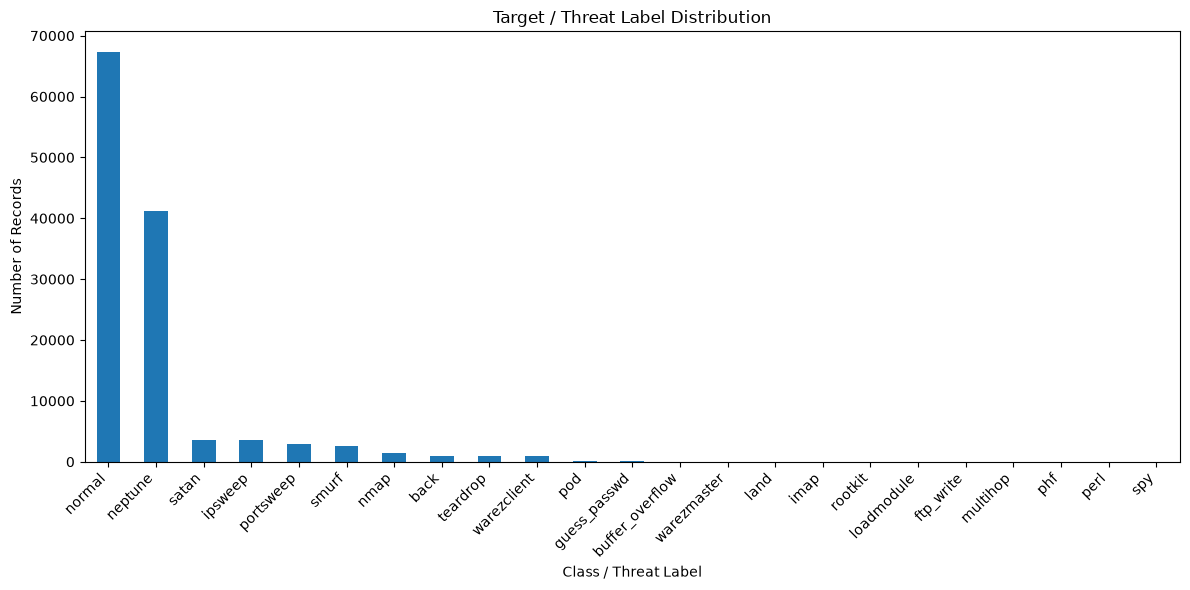

In [ ]:
if target_column is not None:
    plt.figure(figsize=(12, 6))
    df[target_column].astype(str).value_counts().plot(kind="bar")
    plt.title("Target / Threat Label Distribution")
    plt.xlabel("Class / Threat Label")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 11. Identify Categorical Features

Categorical features contain discrete categories or labels rather than continuous numerical measurements.

The identification is based on the pandas data type. Columns with `object`, `category`, or `bool` types are initially considered categorical.

The target column is reported separately as it is not treated as an input feature.

In [ ]:
categorical_features = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

if target_column in categorical_features:
    categorical_input_features = [
        col for col in categorical_features if col != target_column
    ]
else:
    categorical_input_features = categorical_features

print(f"Categorical input features ({len(categorical_input_features)}):")
print(categorical_input_features)

Categorical input features (3):
['protocol_type', 'service', 'flag']


## 12. Identify Numerical Features

Numerical features contain integer or floating-point measurements.

These features commonly represent network traffic properties such as:

- Duration
- Source and destination bytes
- Counts
- Error rates
- Connection statistics

No scaling or normalization is performed here.

In [ ]:
numerical_features = df.select_dtypes(
    include=["number"]
).columns.tolist()

if target_column in numerical_features:
    numerical_input_features = [
        col for col in numerical_features if col != target_column
    ]
else:
    numerical_input_features = numerical_features

print(f"Numerical input features ({len(numerical_input_features)}):")
print(numerical_input_features)

Numerical input features (39):
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty']


## 13. Feature Cardinality Analysis

Cardinality represents the number of unique values in a column.

High-cardinality categorical features may require special consideration during later encoding. Low-cardinality features may provide useful categorical groupings.

This section only identifies the characteristics; it does not encode or transform any feature.

In [1]:
cardinality_summary = pd.DataFrame({
    "column": df.columns,
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns],
    "unique_percentage": [
        round(df[col].nunique(dropna=True) / len(df) * 100, 2)
        if len(df) else 0
        for col in df.columns
    ],
    "dtype": [str(df[col].dtype) for col in df.columns]
}).sort_values("unique_values", ascending=False)

display(cardinality_summary)

NameError: name 'pd' is not defined

## 14. Numerical Feature Summary

Descriptive statistics are calculated for numerical features.

The analysis helps identify:

- Minimum and maximum values
- Central tendency
- Spread
- Potentially unusual values
- Features with very low or very high variance

These values are inspected only. Outliers are not removed in this issue.

In [ ]:
if numerical_input_features:
    numerical_summary = df[numerical_input_features].describe().T
    numerical_summary["missing_count"] = df[numerical_input_features].isna().sum()
    numerical_summary["unique_values"] = df[numerical_input_features].nunique()
    display(numerical_summary)
else:
    print("No numerical input features were detected.")

,count,mean,std,min,25%,50%,75%,max,missing_count,unique_values
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04,0,2981
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09,0,3341
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09,0,9326
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00,0,2
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00,0,3
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00,0,4
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01,0,28
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00,0,6
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00,0,2
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03,0,88


## 15. Categorical Feature Distribution

The most frequent values of each categorical feature are displayed.

This helps identify:

- Dominant categories
- Rare categories
- Potentially unexpected categories
- High-cardinality features

Only the top categories are displayed for readability.

In [ ]:
for column in categorical_input_features:
    print(f"\n### {column}")
    distribution = (
        df[column]
        .value_counts(dropna=False)
        .head(15)
        .to_frame("count")
    )
    distribution["percentage"] = (
        distribution["count"] / len(df) * 100
    ).round(2)
    display(distribution)


### protocol_type


,count,percentage
protocol_type,,
tcp,102689,81.52
udp,14993,11.90
icmp,8291,6.58



### service


,count,percentage
service,,
http,40338,32.02
private,21853,17.35
domain_u,9043,7.18
smtp,7313,5.81
ftp_data,6860,5.45
eco_i,4586,3.64
other,4359,3.46
ecr_i,3077,2.44
telnet,2353,1.87



### flag


,count,percentage
flag,,
SF,74945,59.49
S0,34851,27.67
REJ,11233,8.92
RSTR,2421,1.92
RSTO,1562,1.24
S1,365,0.29
SH,271,0.22
S2,127,0.10
RSTOS0,103,0.08


## 16. Important Numerical Feature Distributions

Histograms are generated for numerical features to inspect their distributions.

The plots can reveal:

- Strong skewness
- Concentration near zero
- Long-tailed distributions
- Possible extreme values
- Features with limited variation

The distributions are visualized only. No transformation or scaling is performed.

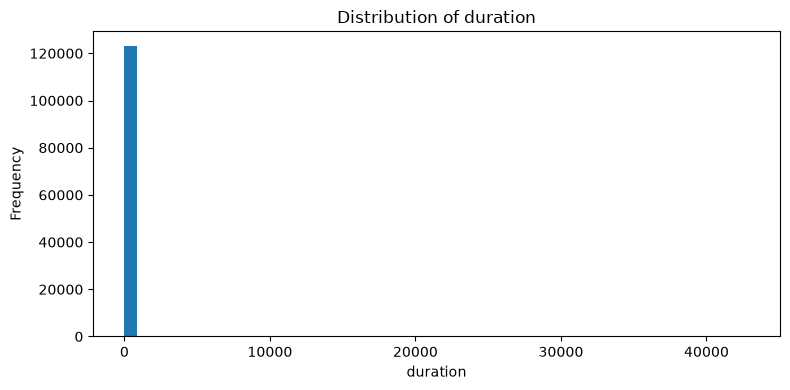

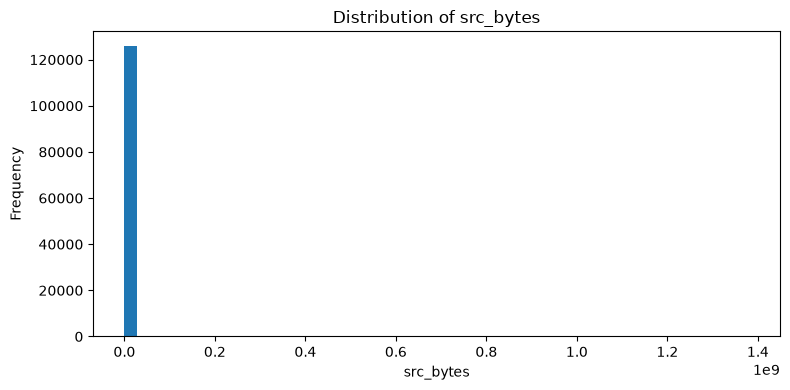

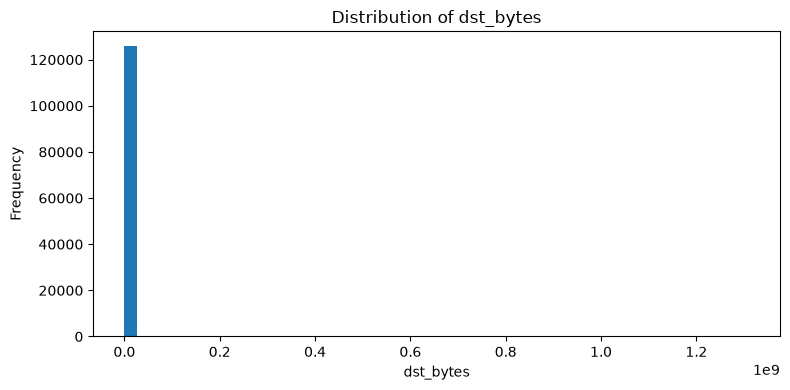

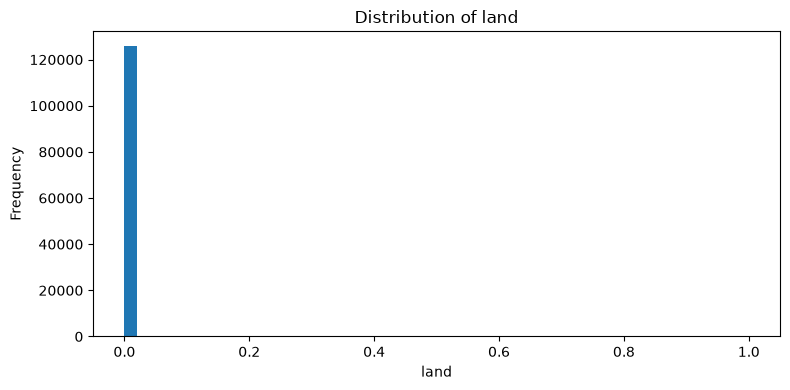

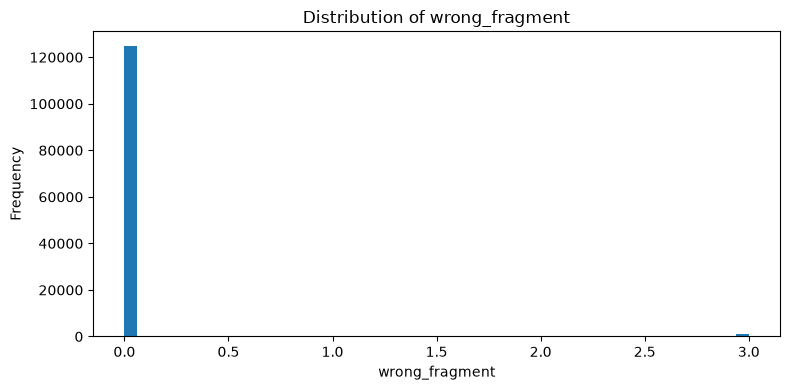

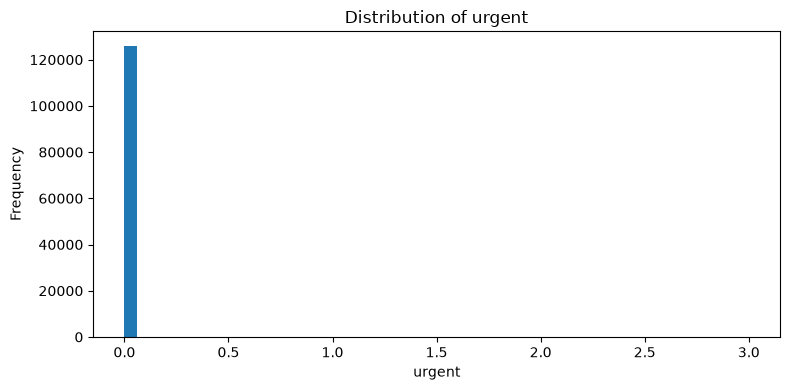

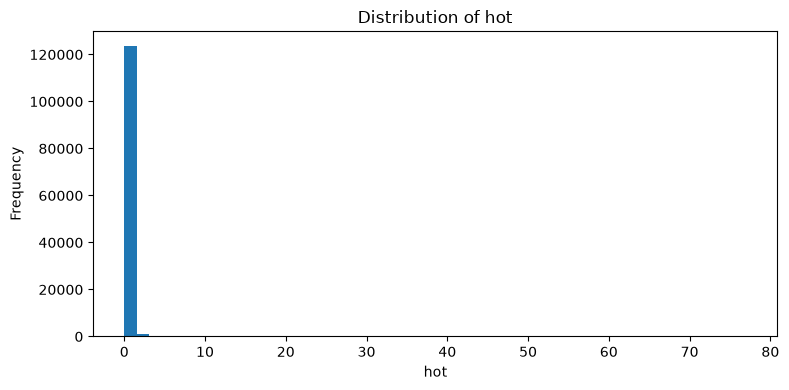

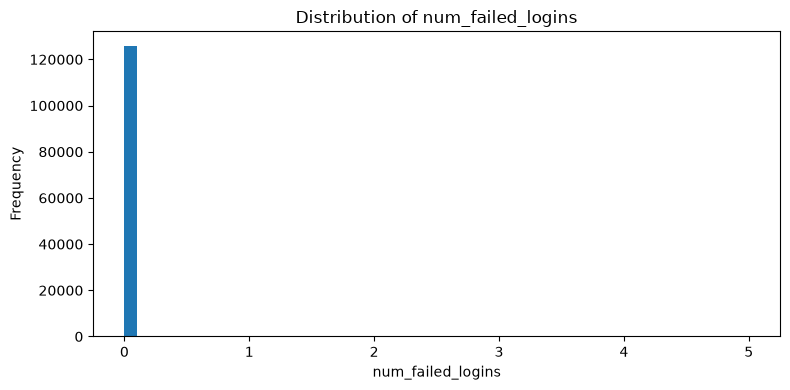

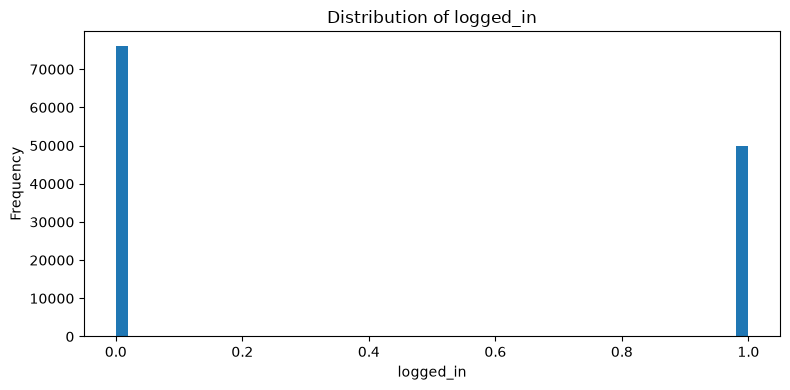

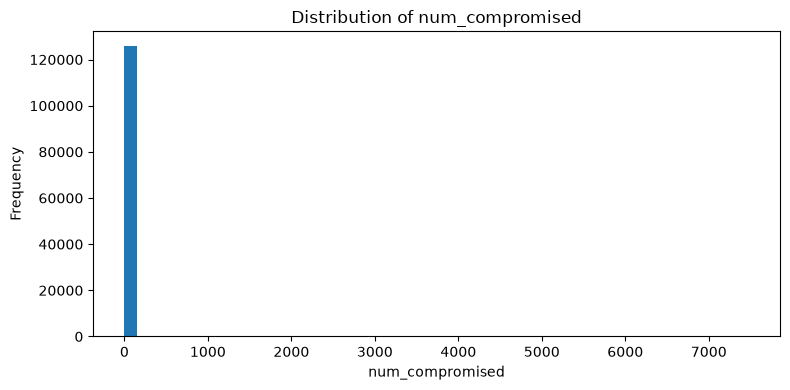

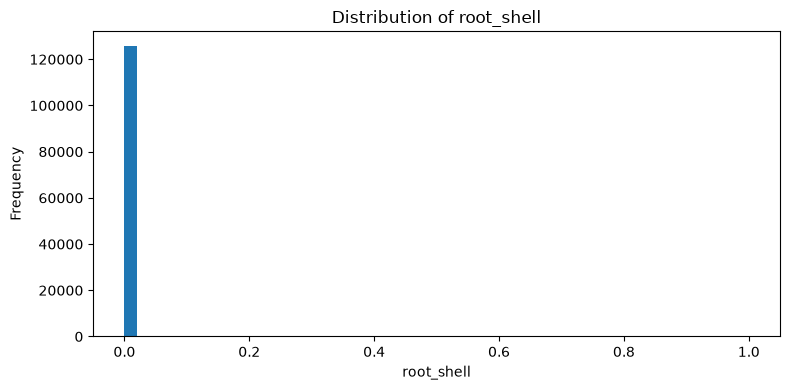

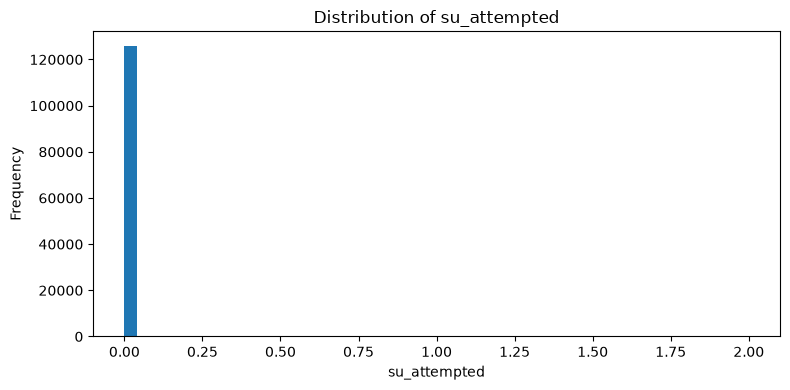

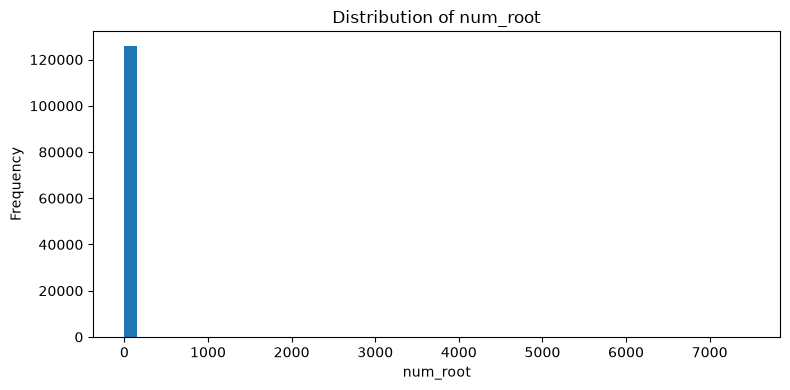

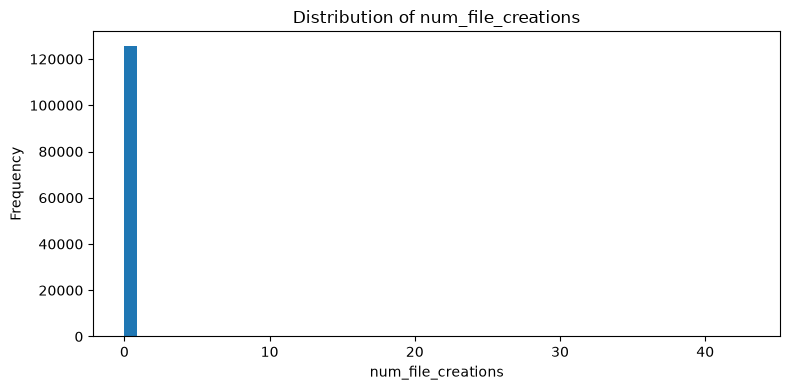

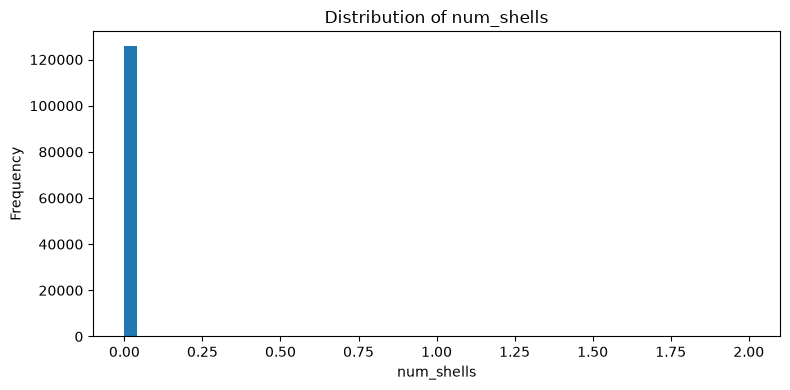

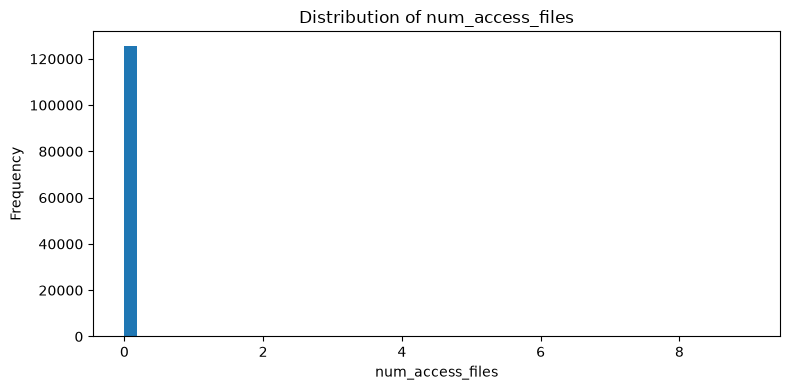

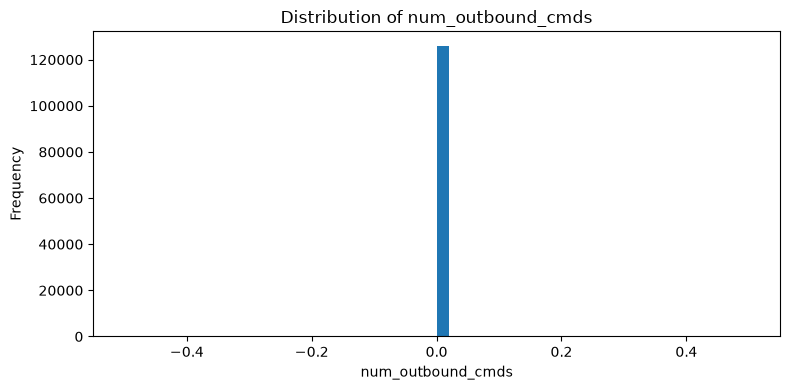

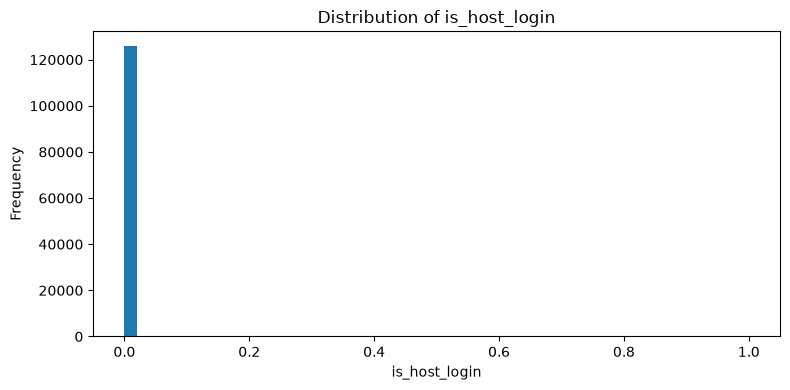

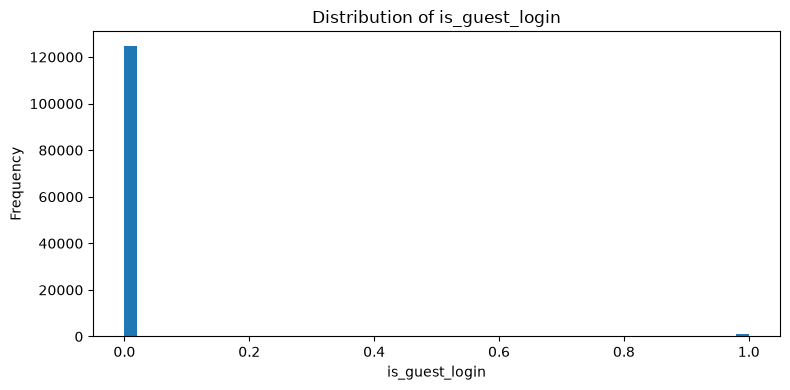

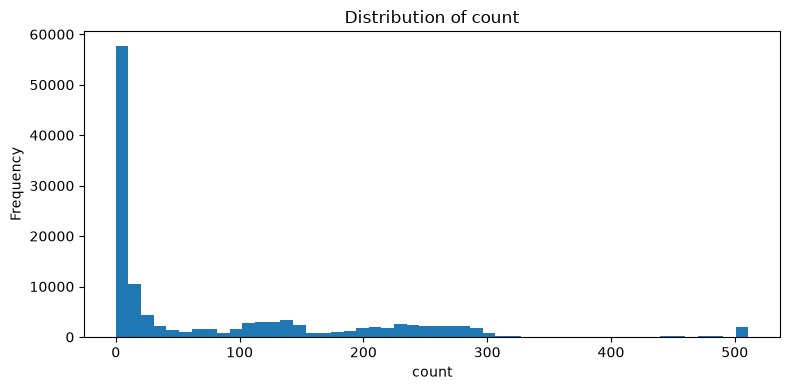

In [ ]:
# Limit the number of plots to keep the notebook readable.
# All numerical features are summarized through statistics above.
MAX_DISTRIBUTION_PLOTS = 20

features_to_plot = numerical_input_features[:MAX_DISTRIBUTION_PLOTS]

for column in features_to_plot:
    plt.figure(figsize=(8, 4))
    df[column].dropna().plot(kind="hist", bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 17. Boxplots for Numerical Features

Boxplots provide another view of the spread and potential extreme values.

An extreme value is not automatically an error. Network traffic data can naturally contain unusual but valid observations. Any treatment of outliers should be decided during the appropriate preprocessing stage.

<Figure size 1000x250 with 0 Axes>

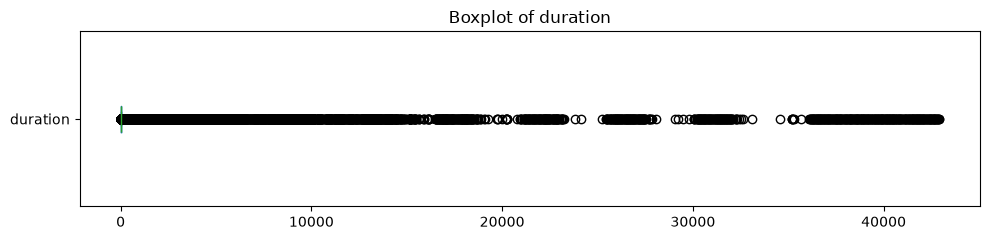

<Figure size 1000x250 with 0 Axes>

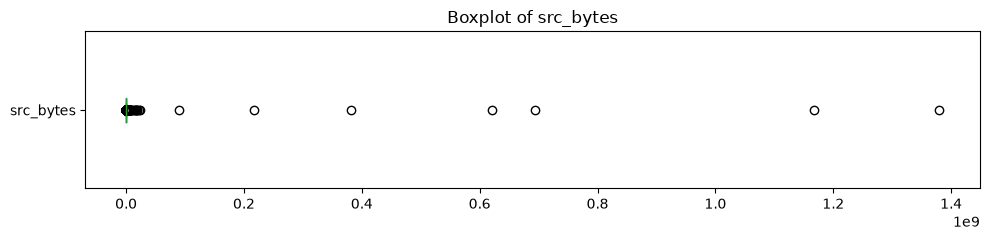

<Figure size 1000x250 with 0 Axes>

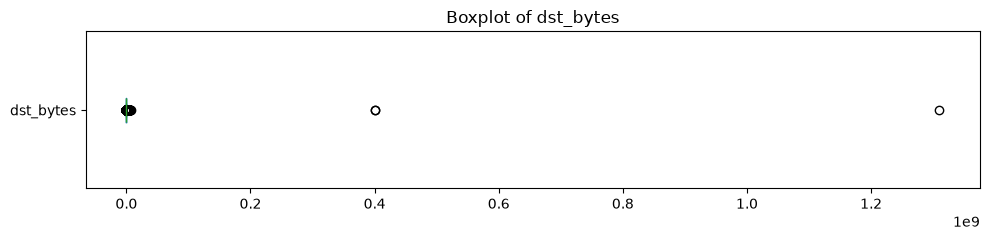

<Figure size 1000x250 with 0 Axes>

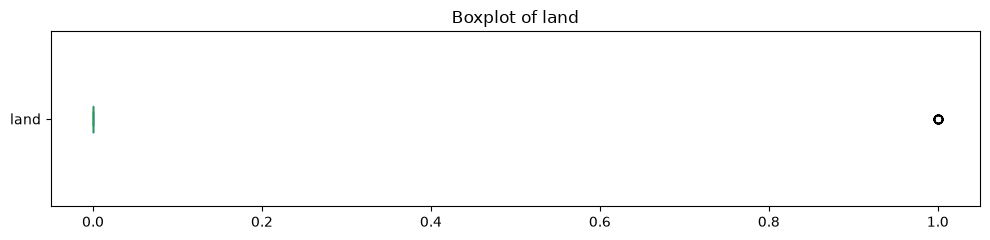

<Figure size 1000x250 with 0 Axes>

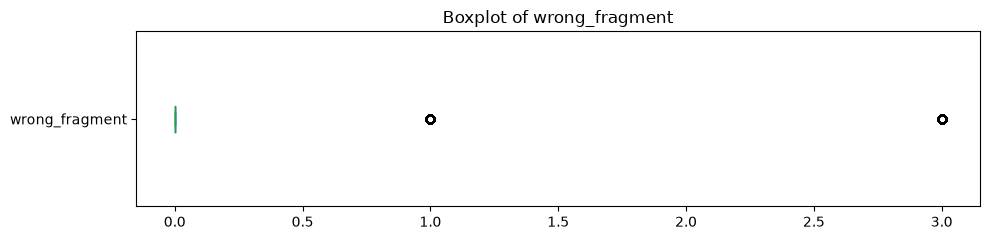

<Figure size 1000x250 with 0 Axes>

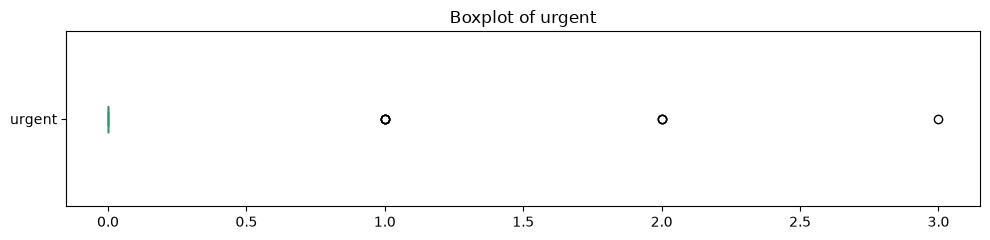

<Figure size 1000x250 with 0 Axes>

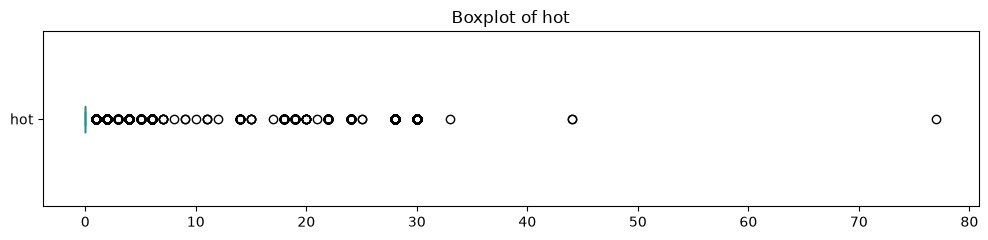

<Figure size 1000x250 with 0 Axes>

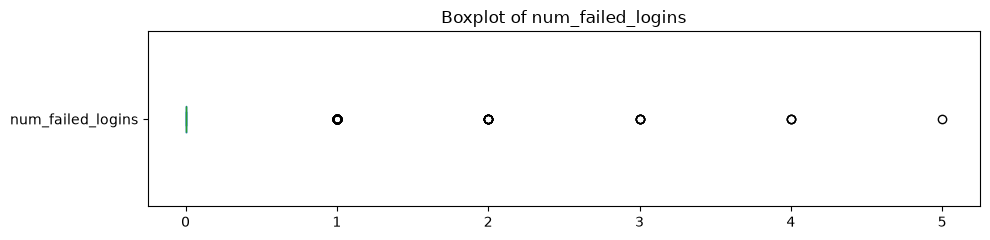

<Figure size 1000x250 with 0 Axes>

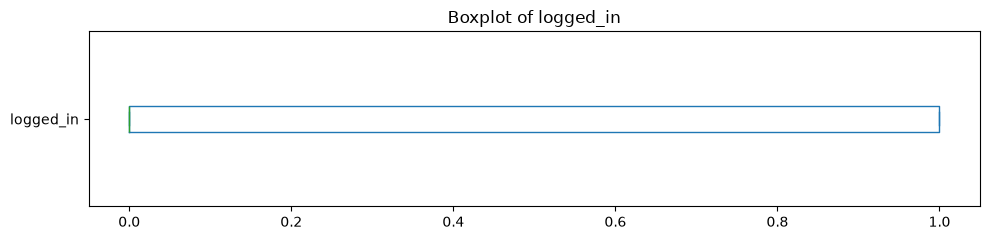

<Figure size 1000x250 with 0 Axes>

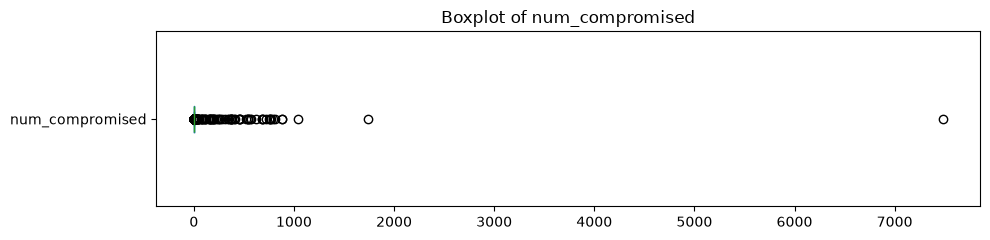

<Figure size 1000x250 with 0 Axes>

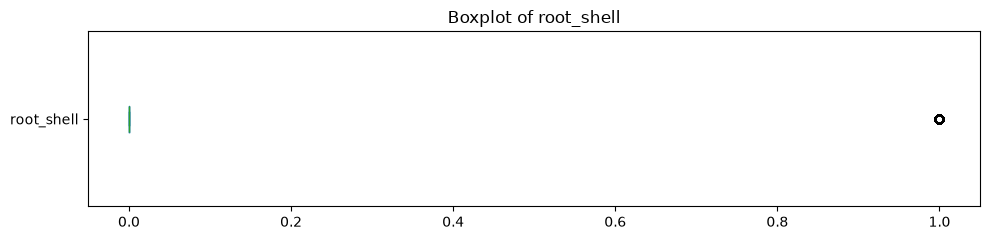

<Figure size 1000x250 with 0 Axes>

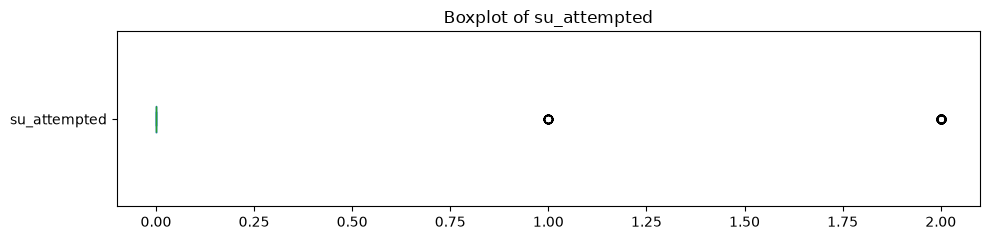

<Figure size 1000x250 with 0 Axes>

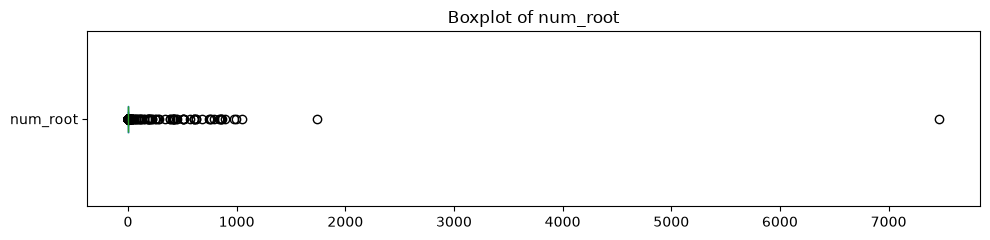

<Figure size 1000x250 with 0 Axes>

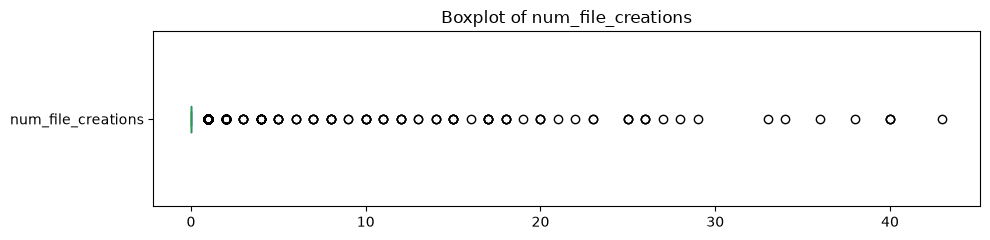

<Figure size 1000x250 with 0 Axes>

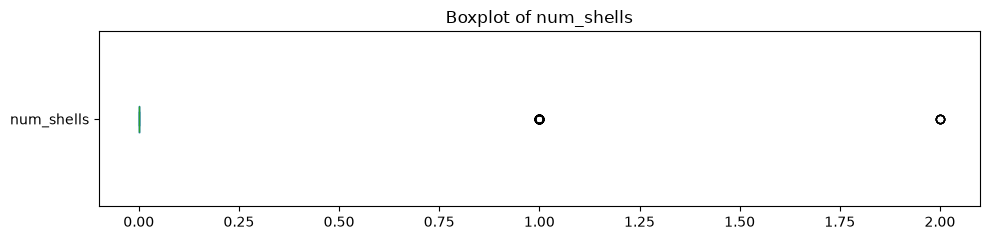

<Figure size 1000x250 with 0 Axes>

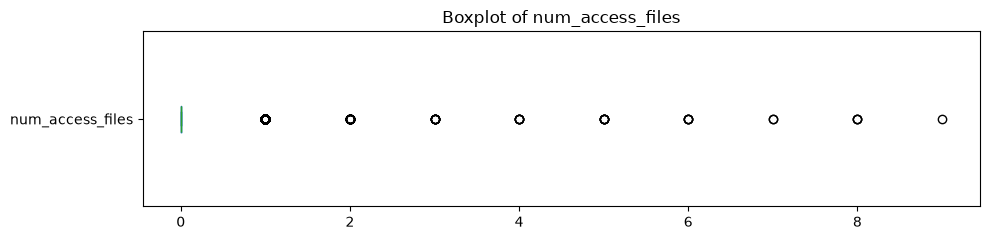

<Figure size 1000x250 with 0 Axes>

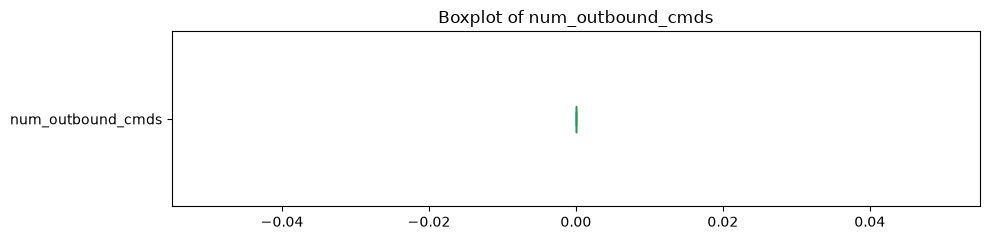

<Figure size 1000x250 with 0 Axes>

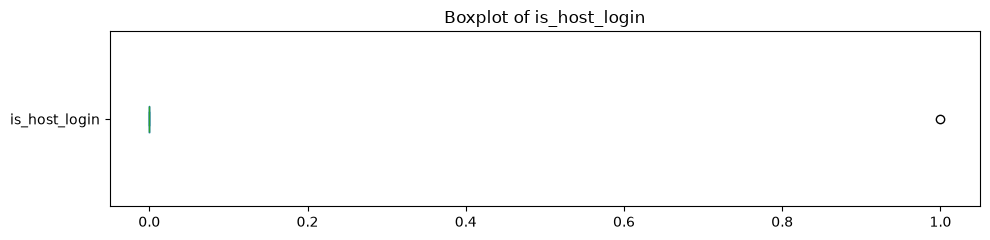

<Figure size 1000x250 with 0 Axes>

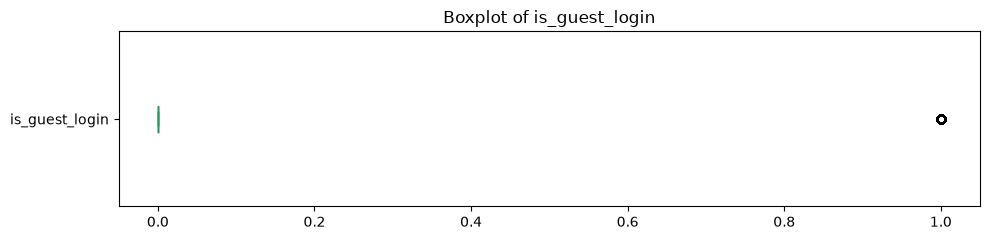

<Figure size 1000x250 with 0 Axes>

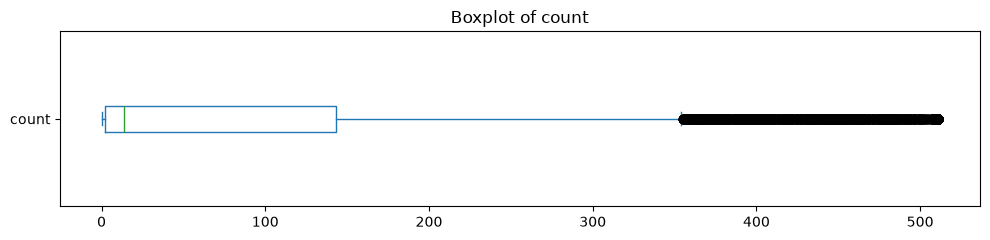

In [ ]:
for column in features_to_plot:
    plt.figure(figsize=(10, 2.5))
    df[[column]].plot(kind="box", vert=False, figsize=(10, 2.5))
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

## 18. Correlation Analysis for Numerical Features

Correlation analysis is used as an exploratory tool to identify relationships among numerical features.

This analysis does not remove features or perform feature selection. It only provides information that may be useful for later feature-selection and modeling decisions.

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
duration,1.00,0.07,0.03,-0.00,-0.01,0.00,0.00,0.01,-0.06,0.04,0.05,0.09,0.05,0.10,-0.00,0.07,NaN,-0.00,0.00,-0.08,-0.04,-0.07,-0.07,0.20,0.20,0.07,-0.01,-0.04,0.05,-0.11,-0.12,0.25,0.23,-0.03,-0.06,-0.06,0.17,0.20,-0.16
src_bytes,0.07,1.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,NaN,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,0.01,0.01,0.00,-0.00,-0.00,-0.01,-0.01,-0.01,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.02
dst_bytes,0.03,0.00,1.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,NaN,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,0.01,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.01,0.01,-0.00,-0.00,-0.00,0.01,0.01,-0.02
land,-0.00,-0.00,-0.00,1.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,NaN,-0.00,-0.00,-0.01,-0.01,0.02,0.02,-0.00,-0.01,0.01,-0.00,0.04,-0.03,-0.01,0.01,-0.00,0.03,0.07,0.02,0.01,-0.01,-0.01,-0.04
wrong_fragment,-0.01,-0.00,-0.00,-0.00,1.00,-0.00,-0.01,-0.00,-0.07,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,NaN,-0.00,-0.01,-0.02,0.02,-0.04,-0.06,-0.03,-0.03,0.05,-0.03,-0.03,0.04,-0.05,-0.05,0.06,0.04,-0.02,-0.05,-0.06,0.03,-0.03,-0.16
urgent,0.00,-0.00,0.00,-0.00,-0.00,1.00,0.00,0.10,0.01,0.03,0.08,0.10,0.03,0.02,-0.00,0.01,NaN,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,-0.00,0.01,0.00,0.01,-0.00,-0.00,-0.00,-0.00,-0.02
hot,0.00,0.00,-0.00,-0.00,-0.01,0.00,1.00,0.00,0.12,0.00,0.02,0.00,0.00,0.03,0.00,-0.00,NaN,0.00,0.86,-0.07,-0.03,-0.06,-0.06,-0.03,-0.03,0.07,-0.02,-0.03,-0.01,-0.05,-0.04,-0.01,-0.03,-0.02,-0.06,-0.06,-0.03,-0.03,-0.16
num_failed_logins,0.01,-0.00,0.00,-0.00,-0.00,0.10,0.00,1.00,-0.01,0.02,0.03,0.07,0.02,0.02,-0.00,0.00,NaN,-0.00,0.01,-0.02,-0.01,-0.02,-0.02,0.02,0.02,0.02,-0.00,-0.01,-0.03,-0.02,-0.00,-0.00,-0.01,0.00,-0.01,-0.01,0.02,0.02,-0.07
logged_in,-0.06,-0.00,-0.00,-0.01,-0.07,0.01,0.12,-0.01,1.00,0.01,0.05,0.03,0.02,0.03,0.02,0.05,NaN,0.00,0.12,-0.54,-0.20,-0.49,-0.49,-0.29,-0.28,0.60,-0.22,0.13,-0.40,0.62,0.60,-0.26,-0.16,-0.06,-0.49,-0.49,-0.28,-0.27,0.27
num_compromised,0.04,-0.00,0.00,-0.00,-0.00,0.03,0.00,0.02,0.01,1.00,0.22,0.36,1.00,0.02,0.00,0.30,NaN,0.00,-0.00,-0.01,-0.00,-0.01,-0.01,-0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.01


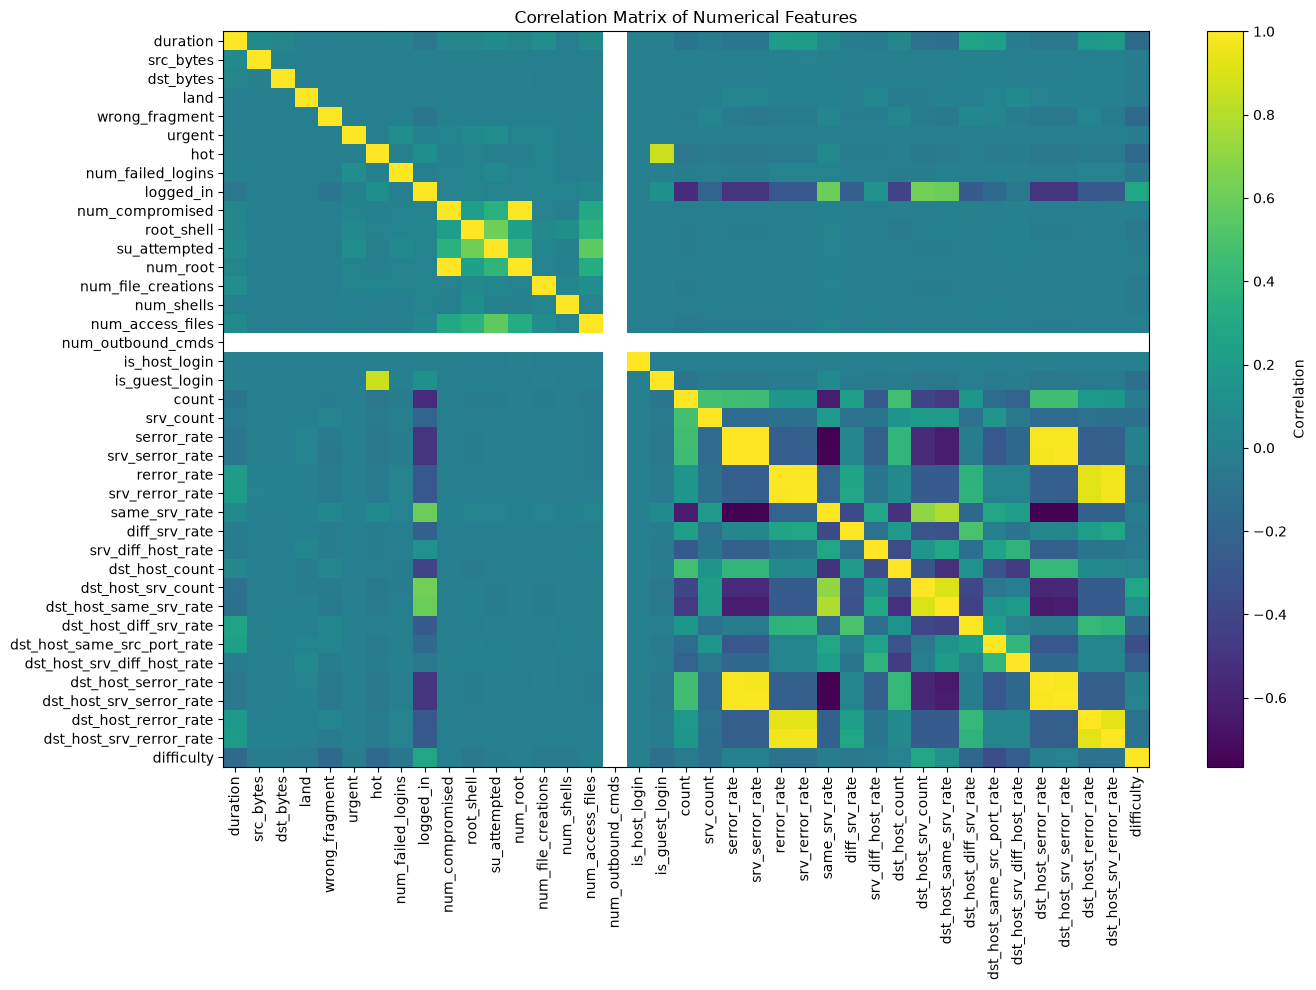

In [ ]:
if len(numerical_input_features) >= 2:
    correlation_matrix = df[numerical_input_features].corr(numeric_only=True)

    display(correlation_matrix.round(2))

    plt.figure(figsize=(14, 10))
    plt.imshow(correlation_matrix, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=90
    )
    plt.yticks(
        range(len(correlation_matrix.index)),
        correlation_matrix.index
    )
    plt.title("Correlation Matrix of Numerical Features")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numerical features are required for correlation analysis.")

## 19. Data Quality Checks

The following potential data quality problems are checked:

- Missing values
- Duplicate records
- Constant features
- Columns with only one unique value
- Infinite numerical values
- Unexpected data types
- Empty strings
- Extremely high-cardinality columns

These problems are documented but not corrected in this issue.

In [ ]:
quality_findings = []

# Missing values
missing_columns = df.columns[df.isna().any()].tolist()
if missing_columns:
    quality_findings.append(
        f"Missing values detected in {len(missing_columns)} column(s): "
        f"{missing_columns}"
    )
else:
    quality_findings.append("No missing values detected.")

# Duplicates
if duplicate_count > 0:
    quality_findings.append(
        f"{duplicate_count:,} exact duplicate record(s) detected "
        f"({duplicate_percentage:.2f}% of the dataset)."
    )
else:
    quality_findings.append("No exact duplicate records detected.")

# Constant columns
constant_columns = [
    col for col in df.columns if df[col].nunique(dropna=False) <= 1
]
if constant_columns:
    quality_findings.append(
        f"Constant or single-value column(s) detected: {constant_columns}"
    )
else:
    quality_findings.append("No constant columns detected.")

# Infinite values
numeric_df = df.select_dtypes(include=["number"])
infinite_counts = np.isinf(numeric_df).sum()
infinite_columns = infinite_counts[infinite_counts > 0].index.tolist()

if infinite_columns:
    quality_findings.append(
        f"Infinite numerical values detected in: {infinite_columns}"
    )
else:
    quality_findings.append("No infinite numerical values detected.")

# Empty strings
empty_string_counts = {}
for col in df.select_dtypes(include=["object"]).columns:
    count = (df[col].astype(str).str.strip() == "").sum()
    if count > 0:
        empty_string_counts[col] = int(count)

if empty_string_counts:
    quality_findings.append(
        f"Empty string values detected: {empty_string_counts}"
    )
else:
    quality_findings.append("No empty string values detected in object columns.")

# High cardinality
high_cardinality_columns = [
    col for col in categorical_input_features
    if df[col].nunique(dropna=True) > 100
]

if high_cardinality_columns:
    quality_findings.append(
        f"High-cardinality categorical feature(s) detected: "
        f"{high_cardinality_columns}"
    )
else:
    quality_findings.append("No categorical features with more than 100 unique values detected.")

for finding in quality_findings:
    print(f"- {finding}")

- No missing values detected.
- No exact duplicate records detected.
- Constant or single-value column(s) detected: ['num_outbound_cmds']
- No infinite numerical values detected.
- No empty string values detected in object columns.
- No categorical features with more than 100 unique values detected.


## 20. Potential Data Quality Issues

The following table summarizes the main data quality indicators discovered during exploration.

In [ ]:
quality_summary = pd.DataFrame({
    "Quality Check": [
        "Missing values",
        "Duplicate records",
        "Constant columns",
        "Infinite numerical values",
        "Empty string values",
        "High-cardinality categorical features"
    ],
    "Result": [
        len(missing_columns) > 0,
        duplicate_count > 0,
        len(constant_columns) > 0,
        len(infinite_columns) > 0,
        len(empty_string_counts) > 0,
        len(high_cardinality_columns) > 0
    ],
    "Details": [
        str(missing_columns) if missing_columns else "None detected",
        f"{duplicate_count:,} ({duplicate_percentage:.2f}%)",
        str(constant_columns) if constant_columns else "None detected",
        str(infinite_columns) if infinite_columns else "None detected",
        str(empty_string_counts) if empty_string_counts else "None detected",
        str(high_cardinality_columns) if high_cardinality_columns else "None detected"
    ]
})

display(quality_summary)

,Quality Check,Result,Details
0,Missing values,False,None detected
1,Duplicate records,False,0 (0.00%)
2,Constant columns,True,['num_outbound_cmds']
3,Infinite numerical values,False,None detected
4,Empty string values,False,None detected
5,High-cardinality categorical features,False,None detected


## 21. Important Observations

The observations below are generated from the exploratory results and should be reviewed before the notebook is committed.

These findings are intended to guide the implementation of the upcoming preprocessing, encoding, scaling, and feature-selection issues.

In [ ]:
observations = []

observations.append(
    f"The dataset contains {len(df):,} records and {df.shape[1]:,} columns."
)

observations.append(
    f"{len(categorical_input_features)} categorical input feature(s) and "
    f"{len(numerical_input_features)} numerical input feature(s) were identified."
)

if missing_columns:
    observations.append(
        f"Missing values were detected in {len(missing_columns)} column(s), "
        "so a missing-value handling strategy should be considered during preprocessing."
    )
else:
    observations.append(
        "No missing values were detected in the loaded dataset."
    )

if duplicate_count > 0:
    observations.append(
        f"{duplicate_count:,} exact duplicate record(s) were detected. "
        "The impact of duplicates should be considered before model training."
    )
else:
    observations.append(
        "No exact duplicate records were detected."
    )

if target_column is not None:
    class_count = df[target_column].nunique(dropna=False)
    observations.append(
        f"The target/threat column is '{target_column}' with "
        f"{class_count} unique class value(s)."
    )

    if len(df) > 0:
        majority_percentage = (
            df[target_column].value_counts(normalize=True, dropna=False).iloc[0] * 100
        )
        if majority_percentage >= 70:
            observations.append(
                f"The largest target class represents approximately "
                f"{majority_percentage:.2f}% of the records, indicating potential class imbalance."
            )
        else:
            observations.append(
                f"The largest target class represents approximately "
                f"{majority_percentage:.2f}% of the records."
            )
else:
    observations.append(
        "The target/threat column could not be identified automatically and should be confirmed manually."
    )

if constant_columns:
    observations.append(
        f"Constant columns were identified: {constant_columns}. "
        "Their usefulness should be evaluated during later feature processing."
    )

if infinite_columns:
    observations.append(
        f"Infinite numerical values were found in {infinite_columns} "
        "and require consideration during data cleaning."
    )

if high_cardinality_columns:
    observations.append(
        f"High-cardinality categorical features were found: {high_cardinality_columns}. "
        "Their encoding strategy should be considered carefully."
    )

for index, observation in enumerate(observations, start=1):
    print(f"{index}. {observation}")

1. The dataset contains 125,973 records and 43 columns.
2. 3 categorical input feature(s) and 39 numerical input feature(s) were identified.
3. No missing values were detected in the loaded dataset.
4. No exact duplicate records were detected.
5. The target/threat column is 'label' with 23 unique class value(s).
6. The largest target class represents approximately 53.46% of the records.
7. Constant columns were identified: ['num_outbound_cmds']. Their usefulness should be evaluated during later feature processing.


## 22. Summary of Dataset Exploration

### Completed

- Dataset loaded from `data/raw/`
- Dataset shape inspected
- Columns and data types documented
- Missing values analyzed
- Duplicate records analyzed
- Target/threat label identified where possible
- Class distribution analyzed
- Categorical features identified
- Numerical features identified
- Numerical feature distributions visualized
- Categorical feature distributions inspected
- Correlations among numerical features explored
- Potential data quality problems checked
- Important observations recorded

### Important boundary

This notebook does **not** perform final cleaning, encoding, scaling, feature selection, or model training.

The findings from this exploration should guide the implementation of Issues 4–7.